In [202]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [203]:
data = pd.read_csv(r"C:\Users\blake\OneDrive\Documents\Resumes\DoorDash Interview\2024 New Verticals Analytics Exercise_9.30.2024.csv", parse_dates=['DELIV_CREATED_AT'])

data.head()

,DELIVERY_UUID,DELIV_CREATED_AT,DELIV_STORE_NAME,DELIV_DASHER_ID,DELIV_SUBMARKET,DELIV_D2R,DELIV_IS_20_MIN_LATE,DELIV_CLAT,DELIV_CANCELLED_AT,DELIV_CANCELLED,DELIV_MISSING_INCORRECT_REPORT,WAS_REQUESTED,WAS_MISSING,WAS_SUBBED,WAS_FOUND,ITEM_NAME,ITEM_PRICE,ITEM_CATEGORY,SUBSTITUTE_ITEM_NAME,SUBSTITUTE_ITEM_CATEGORY
0,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Cupcake Pinot Grigio (750 ml),8.99,Alcohol,NaN,NaN
1,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Meijer Tomato Paste No Salt Added (6 oz),0.90,Pantry,NaN,NaN
2,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Pillsbury Ready To Bake! Cookie Dough Chocolat...,4.25,Bakery,NaN,NaN
3,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Meijer Ultra Pasteurized Heavy Whipping Cream ...,4.05,Dairy & Eggs,NaN,NaN
4,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Maruchan Chicken Flavor Ramen Noodle Soup Box ...,3.95,Pantry,NaN,NaN


In [270]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60585 entries, 0 to 60584
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype          
---  ------                          --------------  -----          
 0   DELIVERY_UUID                   60583 non-null  object         
 1   DELIV_CREATED_AT                60583 non-null  datetime64[ns] 
 2   DELIV_STORE_NAME                60583 non-null  object         
 3   DELIV_DASHER_ID                 59574 non-null  float64        
 4   DELIV_SUBMARKET                 60583 non-null  object         
 5   DELIV_D2R                       59296 non-null  float64        
 6   DELIV_IS_20_MIN_LATE            60583 non-null  float64        
 7   DELIV_CLAT                      58190 non-null  float64        
 8   DELIV_CANCELLED_AT              669 non-null    datetime64[ns] 
 9   DELIV_CANCELLED                 60585 non-null  int64          
 10  DELIV_MISSING_INCORRECT_REPORT  60583 non-null  object    

In [247]:
data['DELIV_CREATED_AT'] = pd.to_datetime(data['DELIV_CREATED_AT'])
data['DELIV_CANCELLED_AT'] = pd.to_datetime(data['DELIV_CANCELLED_AT'])

data['time_to_cancellation'] = data['DELIV_CANCELLED_AT'] - data['DELIV_CREATED_AT']

#data['hour_to_cancellation'] = data['time_to_cancellation'].dt.hour

#data['hour_to_cancellation_to_minutes'] = data['hour_to_cancellation'] * 60

#data['minutes_to_cancellation'] = data['time_to_cancellation'].dt.minute()

In [206]:
data['delivery_day_name'] = data['DELIV_CREATED_AT'].dt.day_name()

In [243]:
data.head()
data.to_csv('cancel.csv', index=False)

In [208]:
data['DELIV_STORE_NAME'].value_counts()

DashMart1    34349
Grocery1     17726
Grocery2      7534
Grocery3       974
Name: DELIV_STORE_NAME, dtype: int64

In [210]:
# there are about 13K unique deliveries, so it doesn't make sense to group by orders

data['DELIVERY_UUID'].nunique()

13085

In [211]:
pivot1 = data.pivot_table(index=['DELIV_STORE_NAME'], values=['ITEM_PRICE'],aggfunc='sum')

In [212]:
pivot1.sort_values(['ITEM_PRICE'], ascending=False)
pivot1

,ITEM_PRICE
DELIV_STORE_NAME,
DashMart1,164504.24
Grocery1,91377.00
Grocery2,39041.38
Grocery3,6134.60


In [213]:
pivot1['Percentage'] = round((pivot1['ITEM_PRICE']  /  pivot1['ITEM_PRICE'].sum()) *100)

In [214]:
pivot1

# Dashmart makes a little over half (55%) of all revenue for the month

,ITEM_PRICE,Percentage
DELIV_STORE_NAME,,
DashMart1,164504.24,55.0
Grocery1,91377.00,30.0
Grocery2,39041.38,13.0
Grocery3,6134.60,2.0


In [248]:
data.describe()

,DELIV_DASHER_ID,DELIV_D2R,DELIV_IS_20_MIN_LATE,DELIV_CLAT,DELIV_CANCELLED,WAS_REQUESTED,WAS_MISSING,WAS_SUBBED,WAS_FOUND,ITEM_PRICE,delivery_month,time_to_cancellation
count,5.957400e+04,59296.000000,60583.000000,58190.000000,60585.000000,60583.0,60583.000000,60583.000000,60583.000000,60583.000000,60583.000000,669
mean,1.068842e+07,4.178952,0.047423,4.535178,0.011042,1.0,0.062493,0.042718,0.932390,4.969335,9.455540,0 days 00:30:38.031390134
std,6.564766e+06,12.389168,0.212543,7.907620,0.104502,0.0,0.242050,0.202223,0.251077,4.209347,0.498024,0 days 00:53:01.728035349
min,2.172560e+05,0.000000,0.000000,0.050000,0.000000,1.0,0.000000,0.000000,0.000000,0.290000,9.000000,0 days 00:00:17
25%,5.250623e+06,0.550000,0.000000,0.283333,0.000000,1.0,0.000000,0.000000,1.000000,2.590000,9.000000,0 days 00:01:47
50%,1.013477e+07,2.716667,0.000000,1.500000,0.000000,1.0,0.000000,0.000000,1.000000,3.990000,9.000000,0 days 00:12:13
75%,1.665884e+07,5.566667,0.000000,5.616667,0.000000,1.0,0.000000,0.000000,1.000000,5.990000,10.000000,0 days 00:33:00
max,2.291942e+07,1313.500000,1.000000,119.783333,1.000000,1.0,1.000000,1.000000,1.000000,160.950000,10.000000,0 days 08:13:19


In [272]:
dashmart_pivot = data.pivot_table(index=['DELIV_STORE_NAME','ITEM_CATEGORY'], values=['ITEM_PRICE'],aggfunc='sum')
dashmart_pivot

ITEM_PRICE
DELIV_STORE_NAME ITEM_CATEGORY                 
DashMart1        Alcohol               17023.01
                 Baby                   1689.98
                 Bakery                 6144.56
                 Candy                 12441.49
                 Dairy & Eggs           6164.21
                 Drinks                35825.48
                 Fresh Food             2611.22
                 Frozen                 6929.57
                 Gifts                   202.17
                 Household              5339.04
                 Ice Cream             18802.21
                 Meat & Fish            3250.59
                 Medicine               3228.05
                 Multicultural             4.58
                 Pantry                 9136.53
                 Personal Care          4890.38
                 Pet Care               2412.85
                 Produce                1792.90
                 Snacks                26615.42
Grocery1         Alcohol                2959.29
                 Baby & Child           1834.30
                 Bakery                 1325.90
                 Beauty                  530.55
                 Candy                  2017.90
                 Dairy & Eggs           8202.30
                 Drinks                 9623.36
                 Electronics             801.15
                 Flowers                 363.25
                 Fresh Food             1560.80
                 Frozen                 8865.40
                 Health                 2326.85
                 Household              8829.70
                 Kitchen                1250.40
                 Meat & Fish            6358.20
                 Medicine                 80.65
                 Pantry                12322.45
                 Personal Care          3760.75
                 Pet Care               3461.90
                 Produce                6314.90
                 Snacks                 7826.15
                 Storage & Cleaning      681.15
                 Vitamins                 79.70
Grocery2         Alcohol                1088.14
                 Baby & Child            924.85
                 Bakery                  975.80
                 Beauty                  299.75
                 Candy                   658.85
                 Dairy & Eggs           3162.05
                 Drinks                 4641.19
                 Electronics             282.35
                 Flowers                 190.65
                 Fresh Food              538.00
                 Frozen                 4030.90
                 Health                 1046.85
                 Household              3365.80
                 Kitchen                 224.40
                 Meat & Fish            2468.65
                 Medicine                 63.85
                 Pantry                 4512.05
                 Personal Care          1556.40
                 Pet Care               2489.35
                 Produce                2300.15
                 Snacks                 3853.55
                 Storage & Cleaning      334.40
                 Vitamins                 33.40
Grocery3         Baby & Child            679.15
                 Bakery                  179.70
                 Candy                   162.40
                 Dairy & Eggs            352.50
                 Drinks                  742.10
                 Fresh Food               90.75
                 Frozen                  732.40
                 Household               602.35
                 Meat & Fish             208.45
                 Medicine                227.65
                 Pantry                  448.55
                 Personal Care           561.55
                 Pet Care                222.50
                 Produce                 156.85
                 Snacks                  642.95
                 Vitamins                124.75

In [215]:
pivot2 = data.pivot_table(index=['ITEM_CATEGORY'], values=['ITEM_PRICE'],aggfunc='sum')

In [216]:

pivot2['Percentage'] =  round((pivot2['ITEM_PRICE'] / pivot2['ITEM_PRICE'].sum()) * 100)
pivot2 = pivot2.sort_values(['ITEM_PRICE'], ascending=False)
pivot2

# drinks, snacks and pantry drive the most revenue

,ITEM_PRICE,Percentage
ITEM_CATEGORY,,
Drinks,50832.13,17.0
Snacks,38938.07,13.0
Pantry,26419.58,9.0
Alcohol,21070.44,7.0
Frozen,20558.27,7.0
Ice Cream,18802.21,6.0
Household,18136.89,6.0
Dairy & Eggs,17881.06,6.0
Candy,15280.64,5.0


<Axes: ylabel='ITEM_PRICE'>

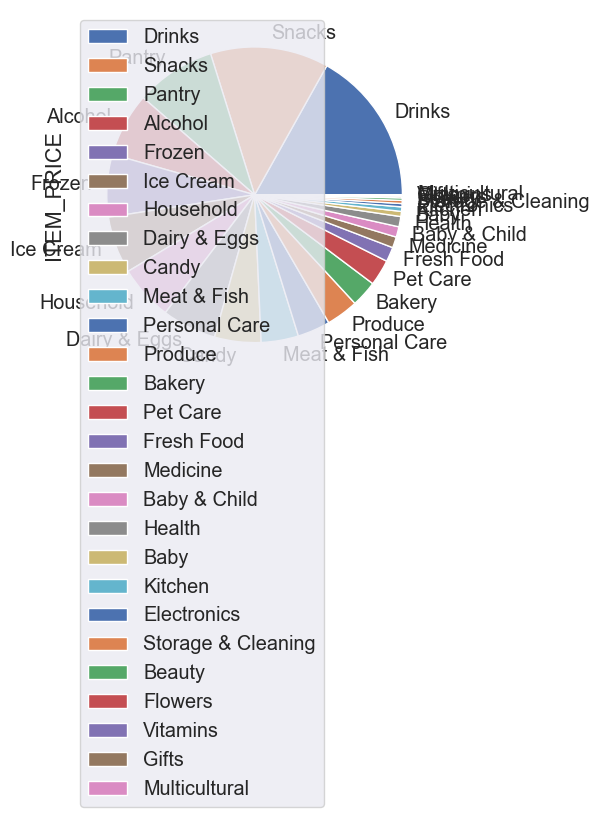

In [218]:
pivot2.plot(kind='pie', y='ITEM_PRICE')

In [220]:
data['delivery_day_name'].value_counts()

Sunday       10439
Thursday      9621
Friday        9334
Saturday      9077
Monday        7905
Wednesday     7408
Tuesday       6799
Name: delivery_day_name, dtype: int64

In [221]:
# earliest date

data['DELIV_CREATED_AT'].min()

Timestamp('2022-09-15 00:00:46')

In [222]:
# most recent date

data['DELIV_CREATED_AT'].max()

Timestamp('2022-10-14 23:59:09')

In [223]:
# time delta

data['DELIV_CREATED_AT'].max() - data['DELIV_CREATED_AT'].min()

Timedelta('29 days 23:58:23')

In [224]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60585 entries, 0 to 60584
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   DELIVERY_UUID                   60583 non-null  object        
 1   DELIV_CREATED_AT                60583 non-null  datetime64[ns]
 2   DELIV_STORE_NAME                60583 non-null  object        
 3   DELIV_DASHER_ID                 59574 non-null  float64       
 4   DELIV_SUBMARKET                 60583 non-null  object        
 5   DELIV_D2R                       59296 non-null  float64       
 6   DELIV_IS_20_MIN_LATE            60583 non-null  float64       
 7   DELIV_CLAT                      58190 non-null  float64       
 8   DELIV_CANCELLED_AT              669 non-null    object        
 9   DELIV_CANCELLED                 60585 non-null  int64         
 10  DELIV_MISSING_INCORRECT_REPORT  60583 non-null  object        
 11  WA

In [226]:
data.head()

,DELIVERY_UUID,DELIV_CREATED_AT,DELIV_STORE_NAME,DELIV_DASHER_ID,DELIV_SUBMARKET,DELIV_D2R,DELIV_IS_20_MIN_LATE,DELIV_CLAT,DELIV_CANCELLED_AT,DELIV_CANCELLED,DELIV_MISSING_INCORRECT_REPORT,WAS_REQUESTED,WAS_MISSING,WAS_SUBBED,WAS_FOUND,ITEM_NAME,ITEM_PRICE,ITEM_CATEGORY,SUBSTITUTE_ITEM_NAME,SUBSTITUTE_ITEM_CATEGORY,delivery_day_name
0,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Cupcake Pinot Grigio (750 ml),8.99,Alcohol,NaN,NaN,Friday
1,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Meijer Tomato Paste No Salt Added (6 oz),0.90,Pantry,NaN,NaN,Friday
2,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Pillsbury Ready To Bake! Cookie Dough Chocolat...,4.25,Bakery,NaN,NaN,Friday
3,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Meijer Ultra Pasteurized Heavy Whipping Cream ...,4.05,Dairy & Eggs,NaN,NaN,Friday
4,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Maruchan Chicken Flavor Ramen Noodle Soup Box ...,3.95,Pantry,NaN,NaN,Friday


In [274]:
data.value_counts('ITEM_CATEGORY').to_csv('item_cat_counts.csv')

In [228]:
data.describe()

,DELIV_DASHER_ID,DELIV_D2R,DELIV_IS_20_MIN_LATE,DELIV_CLAT,DELIV_CANCELLED,WAS_REQUESTED,WAS_MISSING,WAS_SUBBED,WAS_FOUND,ITEM_PRICE
count,5.957400e+04,59296.000000,60583.000000,58190.000000,60585.000000,60583.0,60583.000000,60583.000000,60583.000000,60583.000000
mean,1.068842e+07,4.178952,0.047423,4.535178,0.011042,1.0,0.062493,0.042718,0.932390,4.969335
std,6.564766e+06,12.389168,0.212543,7.907620,0.104502,0.0,0.242050,0.202223,0.251077,4.209347
min,2.172560e+05,0.000000,0.000000,0.050000,0.000000,1.0,0.000000,0.000000,0.000000,0.290000
25%,5.250623e+06,0.550000,0.000000,0.283333,0.000000,1.0,0.000000,0.000000,1.000000,2.590000
50%,1.013477e+07,2.716667,0.000000,1.500000,0.000000,1.0,0.000000,0.000000,1.000000,3.990000
75%,1.665884e+07,5.566667,0.000000,5.616667,0.000000,1.0,0.000000,0.000000,1.000000,5.990000
max,2.291942e+07,1313.500000,1.000000,119.783333,1.000000,1.0,1.000000,1.000000,1.000000,160.950000


In [229]:
data['delivery_month'] = data['DELIV_CREATED_AT'].dt.month

data.head()

,DELIVERY_UUID,DELIV_CREATED_AT,DELIV_STORE_NAME,DELIV_DASHER_ID,DELIV_SUBMARKET,DELIV_D2R,DELIV_IS_20_MIN_LATE,DELIV_CLAT,DELIV_CANCELLED_AT,DELIV_CANCELLED,DELIV_MISSING_INCORRECT_REPORT,WAS_REQUESTED,WAS_MISSING,WAS_SUBBED,WAS_FOUND,ITEM_NAME,ITEM_PRICE,ITEM_CATEGORY,SUBSTITUTE_ITEM_NAME,SUBSTITUTE_ITEM_CATEGORY,delivery_day_name,delivery_month
0,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Cupcake Pinot Grigio (750 ml),8.99,Alcohol,NaN,NaN,Friday,10.0
1,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Meijer Tomato Paste No Salt Added (6 oz),0.90,Pantry,NaN,NaN,Friday,10.0
2,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Pillsbury Ready To Bake! Cookie Dough Chocolat...,4.25,Bakery,NaN,NaN,Friday,10.0
3,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Meijer Ultra Pasteurized Heavy Whipping Cream ...,4.05,Dairy & Eggs,NaN,NaN,Friday,10.0
4,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaN,0,False,1.0,0.0,0.0,1.0,Maruchan Chicken Flavor Ramen Noodle Soup Box ...,3.95,Pantry,NaN,NaN,Friday,10.0


In [276]:
print(data['delivery_day_name'].value_counts())

data['delivery_day_name'].value_counts().to_csv('delivery_day_name.csv')

# deliveries for this vertical are generally highest on Sunday, with Thursday, Friday, Saturday lagging behind slightly. Not surprising considering this is the end of the week. 

Sunday       10439
Thursday      9621
Friday        9334
Saturday      9077
Monday        7905
Wednesday     7408
Tuesday       6799
Name: delivery_day_name, dtype: int64


In [232]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60585 entries, 0 to 60584
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   DELIVERY_UUID                   60583 non-null  object        
 1   DELIV_CREATED_AT                60583 non-null  datetime64[ns]
 2   DELIV_STORE_NAME                60583 non-null  object        
 3   DELIV_DASHER_ID                 59574 non-null  float64       
 4   DELIV_SUBMARKET                 60583 non-null  object        
 5   DELIV_D2R                       59296 non-null  float64       
 6   DELIV_IS_20_MIN_LATE            60583 non-null  float64       
 7   DELIV_CLAT                      58190 non-null  float64       
 8   DELIV_CANCELLED_AT              669 non-null    object        
 9   DELIV_CANCELLED                 60585 non-null  int64         
 10  DELIV_MISSING_INCORRECT_REPORT  60583 non-null  object        
 11  WA

C:\Users\blake\AppData\Local\Temp\ipykernel_10132\808255077.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data.corr(), annot=True, annot_kws={'fontsize':8})


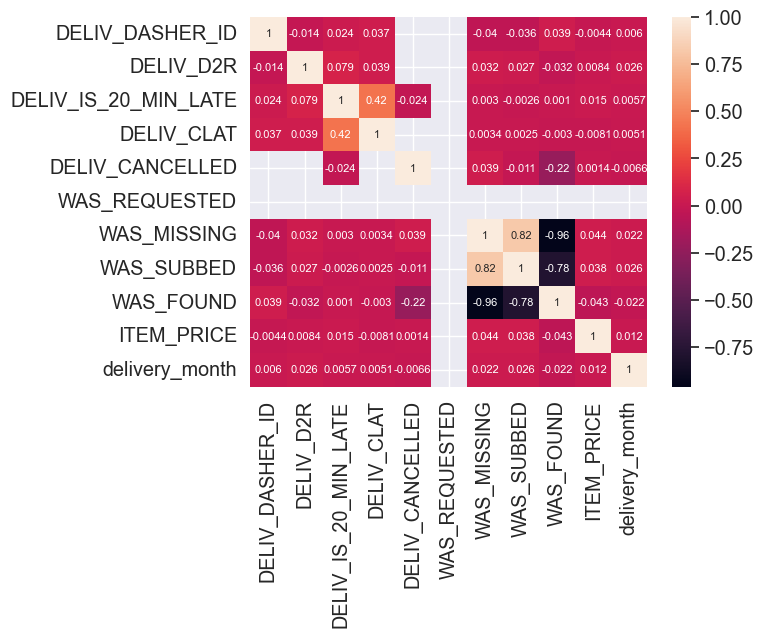

<Figure size 10000x10000 with 0 Axes>

In [238]:
sns.heatmap(data.corr(), annot=True, annot_kws={'fontsize':8})
plt.figure(figsize=(100,100))
plt.show()

# was_missing & was_subbed have a very high positive correlation of 0.82, implying that they are related
#as expected, was_missing & was_found have a strong negative correlation of -0.96, implying that they are inversely related
#We define strong positive correlation as between 0.7 and 0.9 while we define strong negative correlation as between -0.7 to -0.9

<Axes: >

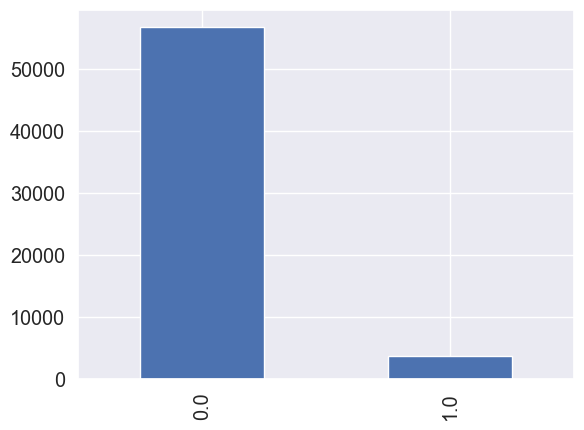

In [250]:
# what items were missing

data['WAS_MISSING'].value_counts().plot.bar()

In [258]:
# pivot_table count for was missing
# the vast majority of deliveries didn't have a missing item. However, about 6% did have a missing item of some sort. Given the high correlation between items that were missing and items that were substituted, this is worth looking into

pivot_was_missing = data.pivot_table(index=['WAS_MISSING'], values=['DELIVERY_UUID'], aggfunc='count')


pivot_was_missing['Percentage'] = round((pivot_was_missing['DELIVERY_UUID']  /  pivot_was_missing['DELIVERY_UUID'].sum()) *100)

pivot_was_missing

,DELIVERY_UUID,Percentage
WAS_MISSING,,
0.0,56797,94.0
1.0,3786,6.0


In [260]:
data_was_missing = data[data['WAS_MISSING']==1]
data_was_missing.head()

,DELIVERY_UUID,DELIV_CREATED_AT,DELIV_STORE_NAME,DELIV_DASHER_ID,DELIV_SUBMARKET,DELIV_D2R,DELIV_IS_20_MIN_LATE,DELIV_CLAT,DELIV_CANCELLED_AT,DELIV_CANCELLED,DELIV_MISSING_INCORRECT_REPORT,WAS_REQUESTED,WAS_MISSING,WAS_SUBBED,WAS_FOUND,ITEM_NAME,ITEM_PRICE,ITEM_CATEGORY,SUBSTITUTE_ITEM_NAME,SUBSTITUTE_ITEM_CATEGORY,delivery_day_name,delivery_month,time_to_cancellation
7,9140e853-ea67-4eee-ba76-85fafcc7da6d,2022-10-14 23:59:09,Grocery1,16990594.0,Cincinnati,0.083333,0.0,0.366667,NaT,0,False,1.0,1.0,0.0,0.0,Meijer Grated Cheese Parmesan (8 oz),3.70,Dairy & Eggs,NaN,NaN,Friday,10.0,NaT
21,ad617ed7-1907-4c4c-8d06-9671724c1c20,2022-10-14 23:57:15,Grocery1,606237.0,Cincinnati,6.750000,0.0,0.450000,NaT,0,False,1.0,1.0,1.0,0.0,Quaker Oats Company Granola Bars Chocolate Chi...,2.30,Snacks,Meijer Chewy Granola Bar Chocolate Chunk (8 ct),Snacks,Friday,10.0,NaT
23,ad617ed7-1907-4c4c-8d06-9671724c1c20,2022-10-14 23:57:15,Grocery1,606237.0,Cincinnati,6.750000,0.0,0.450000,NaT,0,False,1.0,1.0,1.0,0.0,Meijer Ripple Potato Chips (10 oz),3.20,Snacks,Meijer Party Size Potato Chips Ripple (15.25 oz),Snacks,Friday,10.0,NaT
38,ad617ed7-1907-4c4c-8d06-9671724c1c20,2022-10-14 23:57:15,Grocery1,606237.0,Cincinnati,6.750000,0.0,0.450000,NaT,0,False,1.0,1.0,1.0,0.0,Daisy Brand Pure & Natural Sour Cream (8 oz),1.95,Dairy & Eggs,Meijer Sour Cream (8 oz),Dairy & Eggs,Friday,10.0,NaT
51,ad617ed7-1907-4c4c-8d06-9671724c1c20,2022-10-14 23:57:15,Grocery1,606237.0,Cincinnati,6.750000,0.0,0.450000,NaT,0,False,1.0,1.0,1.0,0.0,Meijer Girl Training Pants Jumbo 4T to 5T (18 ct),9.20,Baby & Child,Meijer Girl Training Pants Jumbo 3T to 4T (22 ct),Baby & Child,Friday,10.0,NaT


In [262]:
pivot_was_missing_and_subbed = data_was_missing.pivot_table(index=['WAS_SUBBED'], values=['DELIVERY_UUID'], aggfunc='count')

pivot_was_missing_and_subbed['Percentage'] = round((pivot_was_missing_and_subbed['DELIVERY_UUID']  /  pivot_was_missing_and_subbed['DELIVERY_UUID'].sum()) *100)

pivot_was_missing_and_subbed

# of the deliveries that were missing, 68% were subbed

,DELIVERY_UUID,Percentage
WAS_SUBBED,,
0.0,1198,32.0
1.0,2588,68.0


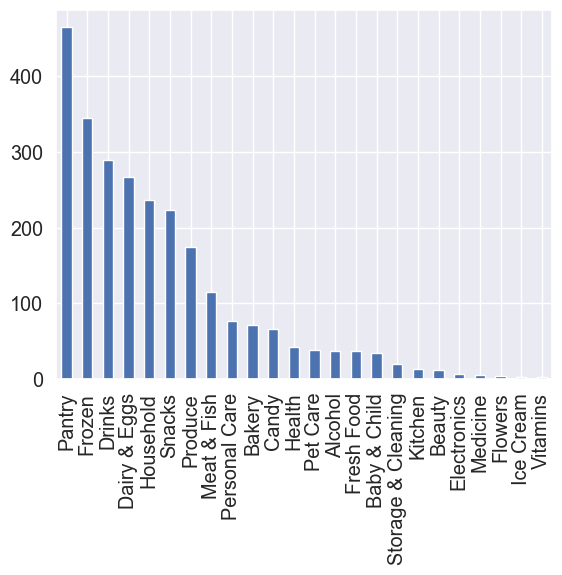

In [277]:
data_was_missing['SUBSTITUTE_ITEM_CATEGORY'].value_counts().plot.bar()

data_was_missing['SUBSTITUTE_ITEM_CATEGORY'].value_counts().to_csv('sub_item_category.csv')

#pantry, frozen, and drinks were the top 3 substitute item categories when there were items missing from the delivery
#potential suggestion is to generate an alert to keep those items extra stocked to our merchants

In [268]:
data_was_missing['SUBSTITUTE_ITEM_CATEGORY'].value_counts()

Pantry                465
Frozen                345
Drinks                289
Dairy & Eggs          267
Household             237
Snacks                224
Produce               175
Meat & Fish           115
Personal Care          77
Bakery                 71
Candy                  66
Health                 42
Pet Care               38
Alcohol                37
Fresh Food             37
Baby & Child           35
Storage & Cleaning     20
Kitchen                13
Beauty                 12
Electronics             7
Medicine                6
Flowers                 4
Ice Cream               3
Vitamins                3
Name: SUBSTITUTE_ITEM_CATEGORY, dtype: int64

In [269]:
pivot_data_20_min_late = data.pivot_table(index=['DELIV_IS_20_MIN_LATE'], values=['DELIVERY_UUID'], aggfunc='count')

pivot_data_20_min_late['Percentage'] = round((pivot_data_20_min_late['DELIVERY_UUID']  /  pivot_data_20_min_late['DELIVERY_UUID'].sum()) *100)

pivot_data_20_min_late


,DELIVERY_UUID,Percentage
DELIV_IS_20_MIN_LATE,,
0.0,57710,95.0
1.0,2873,5.0
